# Compare two simulations 

In [21]:
import os, sys
import subprocess

root_dir = (
    subprocess.run(f"git rev-parse --show-toplevel", shell=True, stdout=subprocess.PIPE)
    .stdout.decode()
    .strip()
)
os.chdir(root_dir)
sys.path.append("lib")
import moccalib as ml

import pandas as pd
pd.options.display.max_columns = None
pd.options.plotting.backend = "plotly"

import matplotlib.pyplot as plt
%matplotlib inline

from importlib import reload


import logging
logging.basicConfig(level="WARNING", format="%(asctime)s|%(levelname)s|%(name)s|%(funcName)s|%(lineno)s|%(message)s")
logger = logging.getLogger()


import re
from pathlib import Path

import plotly.express as px
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook"  # to ensure that nbconvert correctly renders the plotly interactive plots

from tqdm import tqdm


In [25]:
# paths to sims' directories

sims = {  # shows the autocorrelation between the differences between models of identical input parameters
    'test': Path('/work/chuck/mocca/gwiktoro/mocca/src/run/debatri_long_test/'),
    'cleaned': Path('/work/chuck/mocca/gwiktoro/mocca/src/run/debatri_cleaning_long/'),
}
sims = {  # pulsar code development cleanning
    'test': Path('/work/chuck/mocca/gwiktoro/mocca/src/run/debatri_short_test/'),
    'cleaned': Path('/work/chuck/mocca/gwiktoro/mocca/src/run/debatri_cleaning_1/'),
}

# system.dat

In [26]:
headers = [ml.read_header(sim / 'system.dat') for sim in sims.values()]
assert len(headers[0]) > 0, "system.dat header is empty!"
assert all(header.equals(headers[0]) for header in headers[1:]), "system.dat headers are different!"

In [27]:
syss = {name: ml.read_mocca_file(path / 'system.dat') for name, path in tqdm(sims.items())}

100%|███████████████████████████████████████████| 2/2 [00:00<00:00,  8.24it/s]


In [28]:
# Display the comparison of execution statistics
(pd.DataFrame(
    {'name': name, 
     'tphys_max': s.tphys.max(), 
     'timerun_max': s.timerun.max(), 
     'len': len(s)
    } for name, s in syss.items())
 .set_index('name')
 .assign(timerun_per_tphys=lambda x: x.timerun_max / x.tphys_max)
 .T
)

name,test,cleaned
tphys_max,151.000000,151.000000
timerun_max,86.284000,85.712000
len,152.000000,152.000000
timerun_per_tphys,0.571417,0.567629


In [37]:
# compare if the systems are exactly the same
# useful e.g. for code cleaning or refactoring

def compare_systems(systems):
    """ checks if the system.dat files are exactly the same up to the common shape

    If one dataframe is larger, then it's clipped

    Columns related to the execution time or cpu usage are not included in the comparison
    """
    cols_to_drop = ["timerun", "cpuprofiles", "cpuoutput1", "cpuprofiles1", "cputree", "cpusnap", "cpumloss","cpumlossjarr", "cpuoutput", 'cpurelaxall','cpurelax','cpubs','cpubb','cpucoepot','cputimepot','cpuss',"cpuformb3","cpuescape","cpufb","cpumlosssin"]

    min_len = min(len(s) for s in systems)
    logger.debug(f"lengths={[s.shape[0] for s in systems]}; {min_len=}")
    
    systems_clipped = [s.loc[:min_len-1].drop(columns=cols_to_drop, errors='ignore') for s in systems]
    for s in systems_clipped[1:]:
        pd.testing.assert_frame_equal(systems_clipped[0], s, check_dtype=True, check_exact=False)

logger.setLevel('DEBUG')
compare_systems(syss.values())
print("ALL GOOD - system.dat files are the same")

2024-04-24 08:52:43,516|DEBUG|root|compare_systems|14|lengths=[152, 152]; min_len=152


ALL GOOD - system.dat files are the same


### Examining discrepancies in the system.dat files

In [ ]:
systems = syss.values()

cols_to_drop = ["timerun", "cpuprofiles", "cpuoutput1", "cpuprofiles1", "cputree", "cpusnap", "cpumloss","cpumlossjarr", "cpuoutput", 'cpurelaxall','cpurelax','cpubs','cpubb','cpucoepot','cputimepot','cpuss',"cpuformb3","cpuescape","cpufb","cpumlosssin"]

min_len = min(len(s) for s in systems)
logger.debug(f"lengths={[s.shape[0] for s in systems]}; {min_len=}")

systems_clipped = [s.loc[:min_len-1].drop(columns=cols_to_drop, errors='ignore') for s in systems]
# for s in systems_clipped[1:]:
#     pd.testing.assert_frame_equal(systems_clipped[0], s, check_dtype=True, check_exact=False)

df = (systems_clipped[0] - systems_clipped[1])
df.describe()

In [32]:
var = 'r_h'

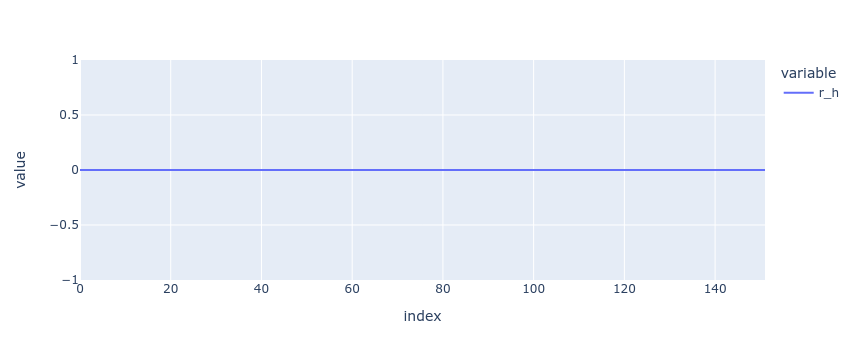

In [33]:
df[var].plot()

/home/gwiktoro/.local/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1490: ValueWarning:

Matrix is singular. Using pinv.



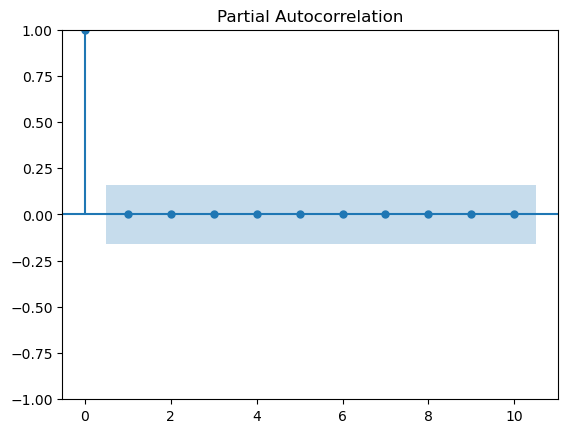

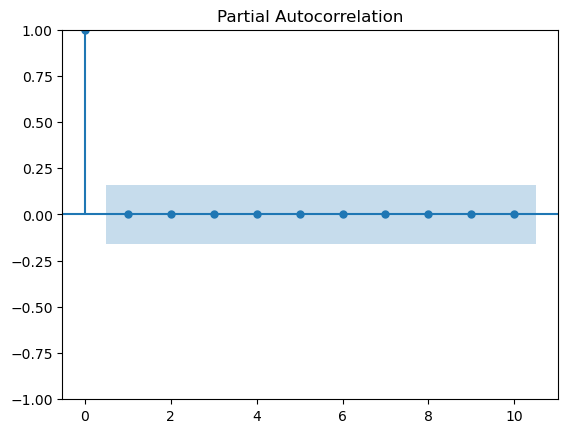

In [34]:
logger.setLevel("WARNING")
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_pacf(df[var], lags=10)

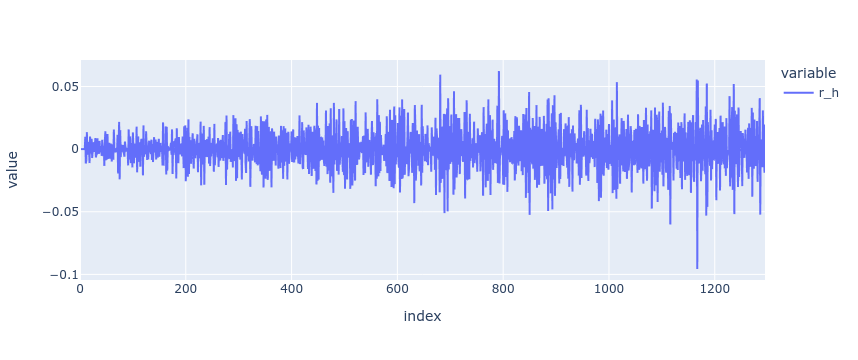

In [23]:
df[var].diff().diff().plot()

In [18]:
from statsmodels.tsa.stattools import adfuller

In [20]:
adfuller(df[var].diff().diff().dropna())

(-14.38752036384231,
 8.937954249596365e-27,
 22,
 1271,
 {'1%': -3.435505433591483,
  '5%': -2.8638166766491344,
  '10%': -2.567982124367278},
 -8143.7813515200505)

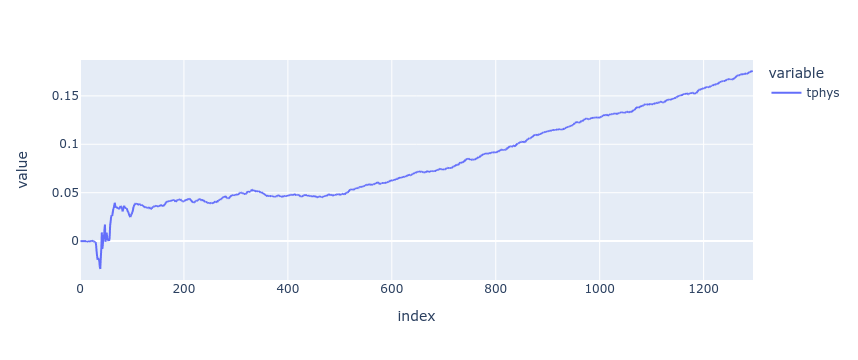

In [24]:
df.tphys.diff().plot()

In [73]:
import numpy as np
adfuller(np.random.normal(size=100))

(-9.435539962308868,
 5.054281838430231e-16,
 0,
 99,
 {'1%': -3.498198082189098,
  '5%': -2.891208211860468,
  '10%': -2.5825959973472097},
 255.34823915393696)

In [74]:
y = np.random.normal(size=100)
y2 = y.cumsum()

In [75]:
adfuller(y2)

(-0.7764134767906965,
 0.8259524472608314,
 0,
 99,
 {'1%': -3.498198082189098,
  '5%': -2.891208211860468,
  '10%': -2.5825959973472097},
 247.8185227580032)

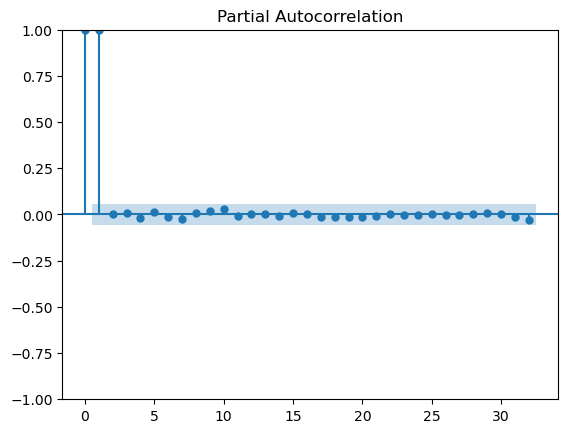

In [76]:
plot_pacf(df.tphys.diff().dropna());